In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px
import sys, os

from pathlib import Path

DATA_DIR = Path("rounds/1_round/data")
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))


In [12]:
files = [
    "prices_round_1_day_-1.csv",
    "prices_round_1_day_-2.csv",
    "prices_round_1_day_0.csv"
]

dfs = [pd.read_csv(f, sep=';') for f in files]
full_prices = pd.concat(dfs, ignore_index=True)

full_prices.head()


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,INTARIAN_PEPPER_ROOT,10991.0,15.0,NaN,NaN,NaN,NaN,11006.0,10.0,11009.0,15.0,NaN,NaN,10998.5,0.0
1,-1,0,ASH_COATED_OSMIUM,NaN,NaN,NaN,NaN,NaN,NaN,10003.0,29.0,NaN,NaN,NaN,NaN,10003.0,0.0
2,-1,100,ASH_COATED_OSMIUM,9984.0,11.0,NaN,NaN,NaN,NaN,10000.0,11.0,10003.0,22.0,NaN,NaN,9992.0,0.0
3,-1,100,INTARIAN_PEPPER_ROOT,10994.0,9.0,10991.0,21.0,NaN,NaN,11006.0,9.0,11009.0,21.0,NaN,NaN,11000.0,0.0
4,-1,200,ASH_COATED_OSMIUM,9985.0,15.0,9982.0,20.0,NaN,NaN,10001.0,15.0,10003.0,20.0,NaN,NaN,9993.0,0.0


In [28]:
#ash = full_prices[full_prices["product"] == "ASH_COATED_OSMIUM"].copy()
#ash = ash.sort_values("timestamp").reset_index(drop=True)

#ash.head()


price_df = pd.read_csv("prices_round_1_day_-1.csv" , sep = ';')

#price_df.head(5)
pd.set_option("display.max_rows", 200)

ash_df = price_df[price_df['product']=='ASH_COATED_OSMIUM'].reset_index(drop=True)
ash_df.iloc[100:200]


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
100,-1,10000,ASH_COATED_OSMIUM,9988.0,14.0,9986.0,28.0,NaN,NaN,10007.0,28.0,NaN,NaN,NaN,NaN,9997.5,0.0
101,-1,10100,ASH_COATED_OSMIUM,9988.0,15.0,9986.0,24.0,NaN,NaN,10004.0,15.0,NaN,NaN,NaN,NaN,9996.0,0.0
102,-1,10200,ASH_COATED_OSMIUM,9988.0,13.0,9986.0,26.0,NaN,NaN,10004.0,13.0,10007.0,26.0,NaN,NaN,9996.0,0.0
103,-1,10300,ASH_COATED_OSMIUM,9988.0,13.0,NaN,NaN,NaN,NaN,10004.0,13.0,10007.0,27.0,NaN,NaN,9996.0,0.0
104,-1,10400,ASH_COATED_OSMIUM,9986.0,28.0,NaN,NaN,NaN,NaN,10005.0,14.0,10007.0,28.0,NaN,NaN,9995.5,0.0
105,-1,10500,ASH_COATED_OSMIUM,9988.0,15.0,9986.0,29.0,NaN,NaN,10004.0,15.0,10007.0,29.0,NaN,NaN,9996.0,0.0
106,-1,10600,ASH_COATED_OSMIUM,9989.0,15.0,9987.0,29.0,NaN,NaN,10005.0,15.0,10008.0,29.0,NaN,NaN,9997.0,0.0
107,-1,10700,ASH_COATED_OSMIUM,9989.0,10.0,9986.0,28.0,NaN,NaN,10005.0,10.0,10007.0,28.0,NaN,NaN,9997.0,0.0
108,-1,10800,ASH_COATED_OSMIUM,9986.0,22.0,NaN,NaN,NaN,NaN,10004.0,15.0,10007.0,22.0,NaN,NaN,9995.0,0.0
109,-1,10900,ASH_COATED_OSMIUM,9986.0,27.0,NaN,NaN,NaN,NaN,10004.0,15.0,10007.0,27.0,NaN,NaN,9995.0,0.0


In [28]:
# ══════════════════════════════════════════════════════════════════════════════
# COMPREHENSIVE MEAN-REVERSION / STATIONARITY SUITE — ASH_COATED_OSMIUM
# Tests: ADF, KPSS, Phillips-Perron, Hurst exponent, OU half-life,
#        Variance-Ratio, ACF/PACF diagnostics
# ══════════════════════════════════════════════════════════════════════════════
import warnings, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.tsa.stattools import adfuller as _adf
from statsmodels.regression.linear_model import OLS
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm

warnings.filterwarnings("ignore", category=FutureWarning)

# ── helpers ───────────────────────────────────────────────────────────────────
def _clean(x):
    x = pd.to_numeric(x, errors="coerce").replace([np.inf, -np.inf], np.nan).dropna()
    return x

def _logret(x):
    x = _clean(x); x = x[x > 0]
    return np.log(x).diff().replace([np.inf, -np.inf], np.nan).dropna()

# ── build series ──────────────────────────────────────────────────────────────
ash = full_prices[full_prices["product"] == "ASH_COATED_OSMIUM"].copy()
ash = ash.sort_values(["day", "timestamp"]).reset_index(drop=True)
if "mid_price" in ash.columns and ash["mid_price"].notna().any():
    ash["price"] = pd.to_numeric(ash["mid_price"], errors="coerce")
else:
    ash["price"] = (
        pd.to_numeric(ash["bid_price_1"], errors="coerce")
        + pd.to_numeric(ash["ask_price_1"], errors="coerce")
    ) / 2.0

p_all = _clean(ash["price"]).values
lr_all = _logret(ash["price"]).values

# ══════════════════════════════════════════════════════════════════════════════
# 1. UNIT ROOT / STATIONARITY TESTS  (per day + pooled)
# ══════════════════════════════════════════════════════════════════════════════
def _pp(x):
    res = adfuller(x, maxlag=0, regression="c", autolag=None)
    return res[0], res[1]

rows = []
groups = list(ash.groupby("day", sort=True)) + [("ALL", ash)]
for d, g in groups:
    p = _clean(g["price"]); lr = _logret(g["price"])
    if len(p) < 50 or len(lr) < 50:
        continue
    adf_l = adfuller(p, regression="c", autolag="AIC")
    kpss_l = kpss(p, regression="c", nlags="auto")
    pp_l  = _pp(p)
    adf_r = adfuller(lr, regression="c", autolag="AIC")
    kpss_r = kpss(lr, regression="c", nlags="auto")
    pp_r  = _pp(lr)
    rows.append({
        "day": int(d) if d != "ALL" else "ALL", "n": int(len(p)),
        "ADF_p (level)": round(adf_l[1], 4),
        "KPSS_p (level)": f">={kpss_l[1]:.2f}" if kpss_l[1] >= 0.1 else round(kpss_l[1], 4),
        "PP_p (level)": round(pp_l[1], 4),
        "ADF_p (logret)": round(adf_r[1], 4),
        "KPSS_p (logret)": f">={kpss_r[1]:.2f}" if kpss_r[1] >= 0.1 else round(kpss_r[1], 4),
        "PP_p (logret)": round(pp_r[1], 4),
    })
unit_root_df = pd.DataFrame(rows)
print("=" * 80)
print("1. UNIT-ROOT / STATIONARITY TESTS")
print("   ADF/PP: p<0.05 -> reject unit root (stationary)")
print("   KPSS:   p>0.05 -> fail to reject stationarity (stationary)")
print("=" * 80)
display(unit_root_df)

# ══════════════════════════════════════════════════════════════════════════════
# 2. HURST EXPONENT  (rescaled range)
# ══════════════════════════════════════════════════════════════════════════════
def hurst_rs(ts, min_window=20):
    ts = np.asarray(ts, float); n = len(ts)
    max_k = int(np.floor(n / min_window))
    if max_k < 2: return np.nan
    ns, rs_vals = [], []
    for k in range(2, max_k + 1):
        size = n // k
        if size < min_window: break
        rs_list = []
        for i in range(k):
            chunk = ts[i*size:(i+1)*size]
            devs = np.cumsum(chunk - chunk.mean())
            R = devs.max() - devs.min(); S = chunk.std(ddof=1)
            if S > 0: rs_list.append(R / S)
        if rs_list:
            ns.append(size); rs_vals.append(np.mean(rs_list))
    if len(ns) < 3: return np.nan
    return np.polyfit(np.log(ns), np.log(rs_vals), 1)[0]

hurst_level  = hurst_rs(p_all)
hurst_logret = hurst_rs(lr_all)
print("\n" + "=" * 80)
print("2. HURST EXPONENT (rescaled range)")
print("   H < 0.5 -> mean-reverting | H = 0.5 -> random walk | H > 0.5 -> trending")
print("=" * 80)
print(f"   Price level:  H = {hurst_level:.4f}  {'<- mean-reverting' if hurst_level < 0.5 else '<- trending' if hurst_level > 0.5 else '<- random walk'}")
print(f"   Log returns:  H = {hurst_logret:.4f}  {'<- mean-reverting' if hurst_logret < 0.5 else '<- trending' if hurst_logret > 0.5 else '<- random walk'}")

# ══════════════════════════════════════════════════════════════════════════════
# 3. ORNSTEIN-UHLENBECK HALF-LIFE
# ══════════════════════════════════════════════════════════════════════════════
def ou_half_life(prices):
    y = np.asarray(prices, float); dy = np.diff(y); y_lag = y[:-1]
    res = OLS(dy, sm.add_constant(y_lag)).fit()
    theta = -res.params[1]
    if theta <= 0: return np.inf, theta, res.pvalues[1]
    return np.log(2) / theta, theta, res.pvalues[1]

hl, theta, theta_p = ou_half_life(p_all)
print("\n" + "=" * 80)
print("3. OU HALF-LIFE OF MEAN REVERSION (price level)")
print("   Regresses dp on p_{t-1}; theta>0 -> mean-reverting")
print("=" * 80)
print(f"   theta (speed) = {theta:.6f}  (p-value = {theta_p:.4e})")
print(f"   Half-life     = {hl:.1f} ticks")
if hl < np.inf:
    print(f"   Price reverts halfway to mean in ~{hl:.0f} ticks")
else:
    print("   No mean-reversion detected (theta <= 0)")

# ══════════════════════════════════════════════════════════════════════════════
# 4. VARIANCE RATIO TEST
# ══════════════════════════════════════════════════════════════════════════════
def variance_ratio(x, lags=None):
    if lags is None: lags = [2, 4, 8, 16, 32, 64]
    x = np.asarray(x, float); var1 = np.var(np.diff(x), ddof=1)
    results = []
    for q in lags:
        diffs = x[q:] - x[:-q]
        vr = (np.var(diffs, ddof=1) / q) / var1 if var1 > 0 else np.nan
        results.append({"lag": q, "VR": round(vr, 4)})
    return results

vr_results = variance_ratio(p_all)
vr_df = pd.DataFrame(vr_results)
print("\n" + "=" * 80)
print("4. VARIANCE RATIO (price level)")
print("   VR < 1 -> mean-reverting | VR = 1 -> random walk | VR > 1 -> trending")
print("=" * 80)
display(vr_df)


C:\Users\alexn\AppData\Local\Temp\ipykernel_27308\2223329802.py:53: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_l = kpss(p, regression="c", nlags="auto")
C:\Users\alexn\AppData\Local\Temp\ipykernel_27308\2223329802.py:56: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_r = kpss(lr, regression="c", nlags="auto")
C:\Users\alexn\AppData\Local\Temp\ipykernel_27308\2223329802.py:53: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_l = kpss(p, regression="c", nlags="auto")
C:\Users\alexn\AppData\Local\Temp\ipykernel_27308\2223329802.py:56: InterpolationWarning: The test statistic is outside of the range of p-values av

1. UNIT-ROOT / STATIONARITY TESTS
   ADF/PP: p<0.05 -> reject unit root (stationary)
   KPSS:   p>0.05 -> fail to reject stationarity (stationary)


C:\Users\alexn\AppData\Local\Temp\ipykernel_27308\2223329802.py:56: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_r = kpss(lr, regression="c", nlags="auto")


,day,n,ADF_p (level),KPSS_p (level),PP_p (level),ADF_p (logret),KPSS_p (logret),PP_p (logret)
0,-2,10000,0.0,>=0.10,0.0,0.0,>=0.10,0.0
1,-1,10000,0.0,>=0.10,0.0,0.0,>=0.10,0.0
2,0,10000,0.0,>=0.10,0.0,0.0,>=0.10,0.0
3,ALL,30000,0.0,>=0.10,0.0,0.0,>=0.10,0.0



2. HURST EXPONENT (rescaled range)
   H < 0.5 -> mean-reverting | H = 0.5 -> random walk | H > 0.5 -> trending
   Price level:  H = 0.7427  <- trending
   Log returns:  H = 0.2100  <- mean-reverting

3. OU HALF-LIFE OF MEAN REVERSION (price level)
   Regresses dp on p_{t-1}; theta>0 -> mean-reverting
   theta (speed) = 1.001741  (p-value = 0.0000e+00)
   Half-life     = 0.7 ticks
   Price reverts halfway to mean in ~1 ticks

4. VARIANCE RATIO (price level)
   VR < 1 -> mean-reverting | VR = 1 -> random walk | VR > 1 -> trending


,lag,VR
0,2,0.4999
1,4,0.2500
2,8,0.1250
3,16,0.0625
4,32,0.0313
5,64,0.0157


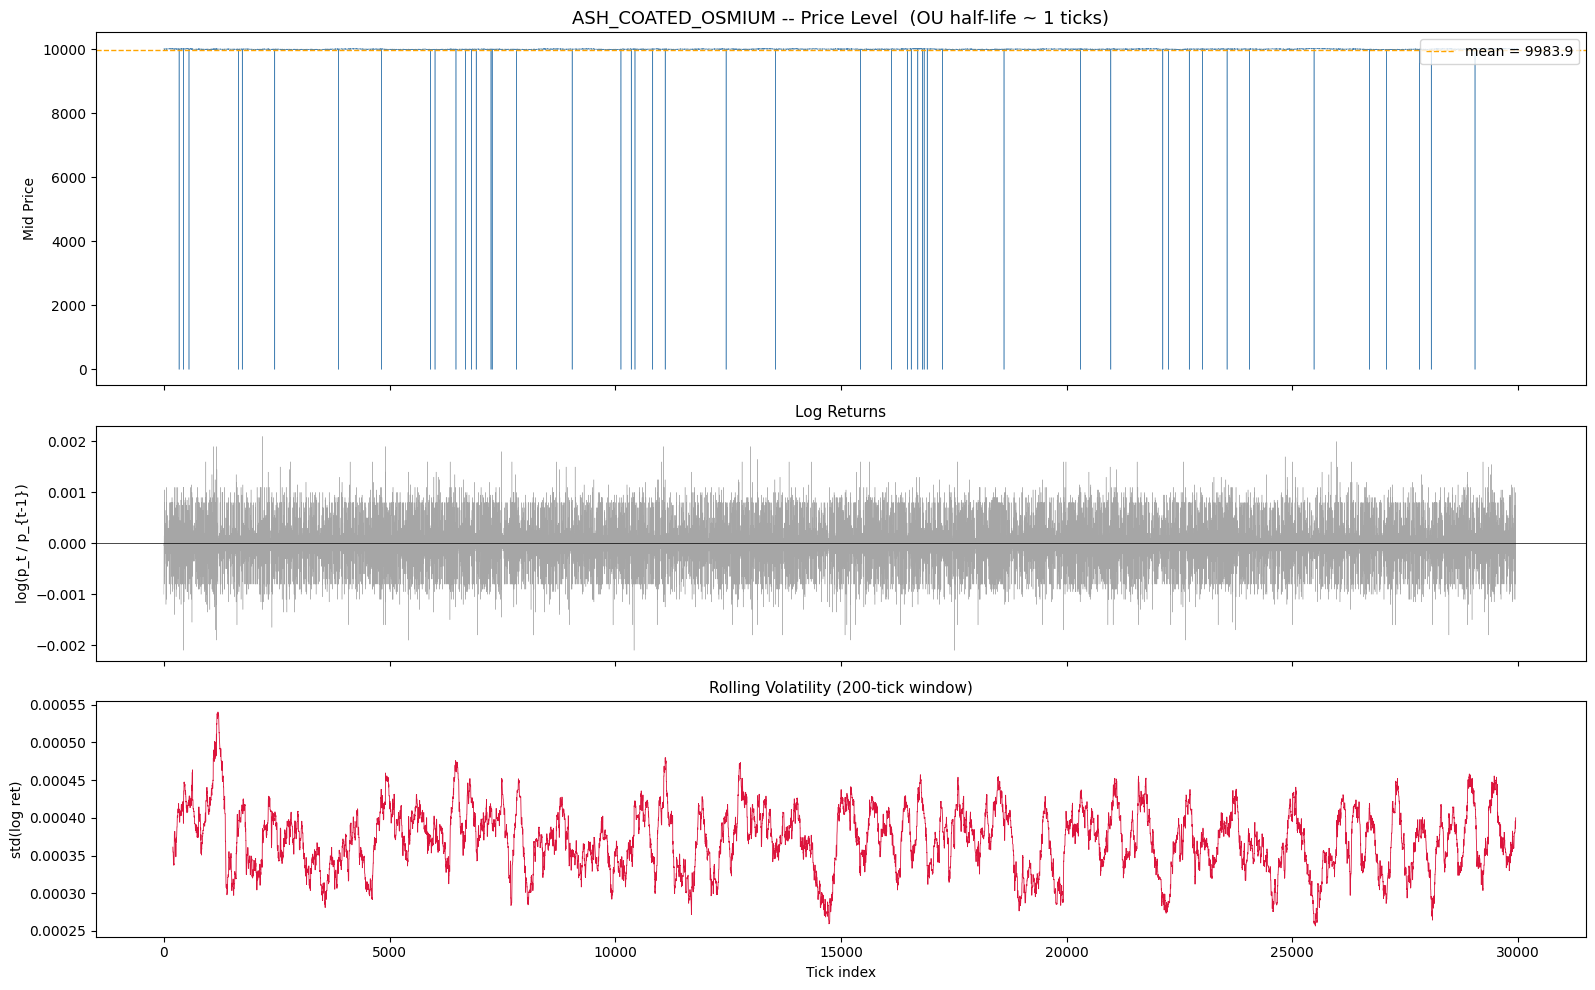

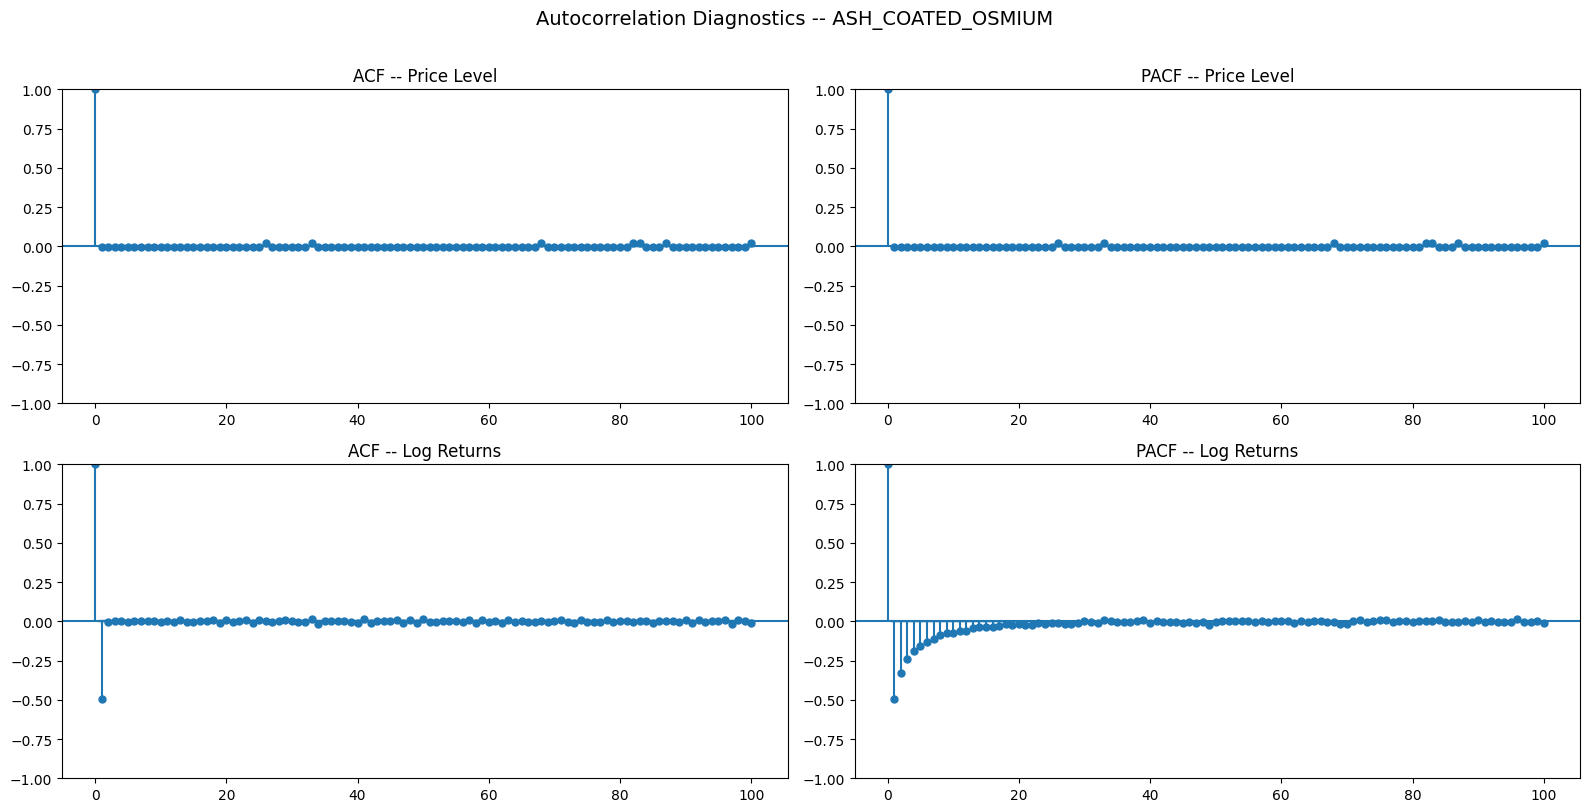

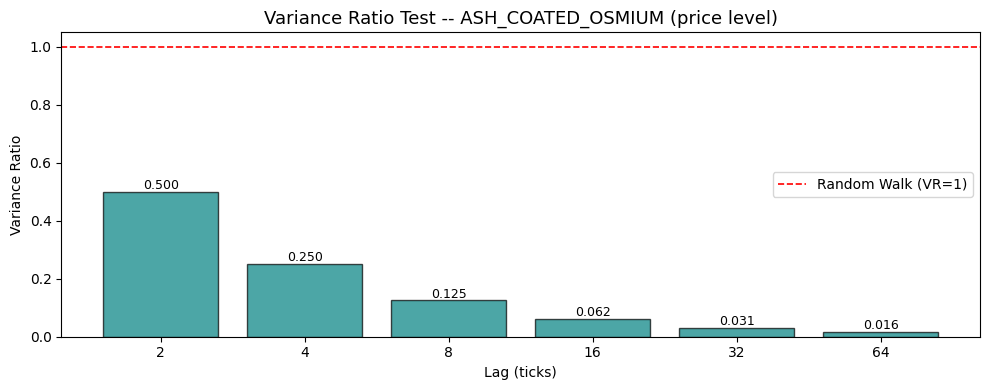

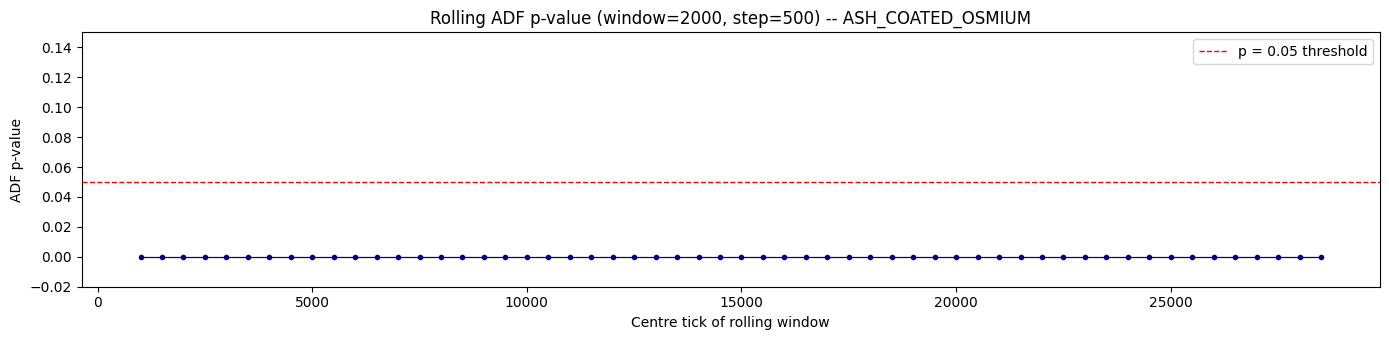

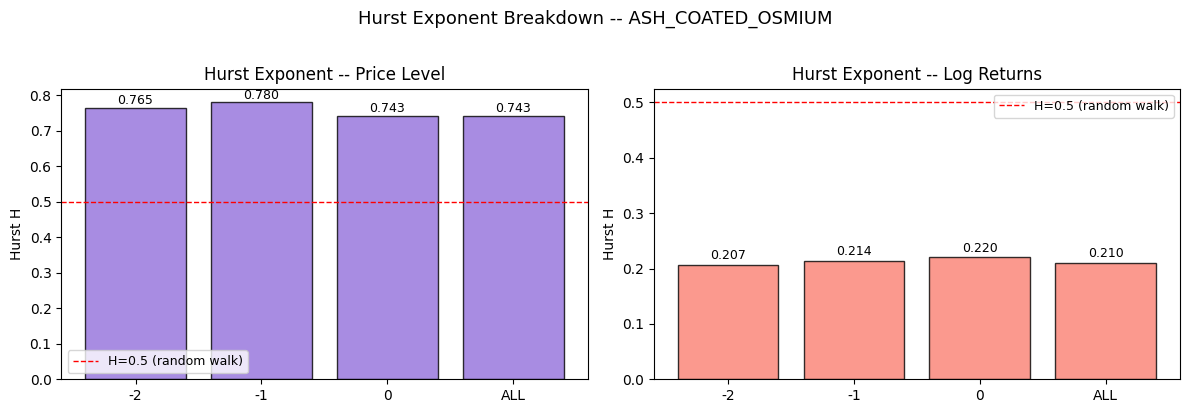

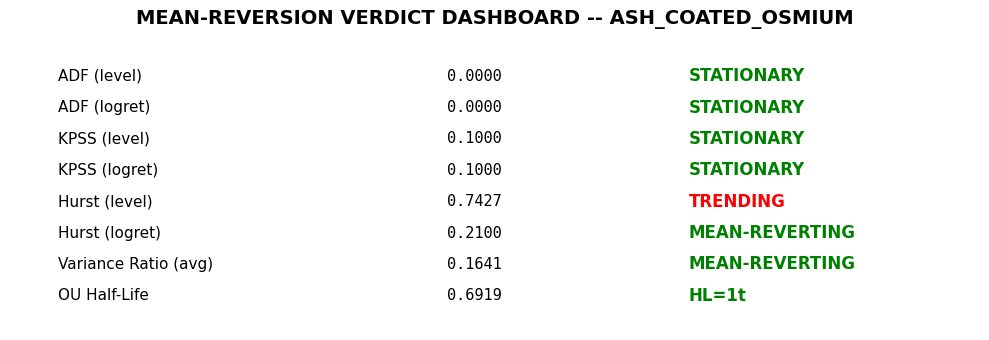


All diagnostics complete.


In [29]:
# =============================================================================
# PLOTLY VISUALISATIONS - MEAN-REVERSION DIAGNOSTICS (run cell 3 first)
# =============================================================================
import plotly.graph_objects as go
from plotly.subplots import make_subplots

NLAGS_ACF = 100
MID_MA_WINDOW = 200
PRICE_SCALE = 100.0   # display price in smaller denomination
RET_SCALE = 10000.0   # display returns in bps

# Clean plotting series: replace literal 0 with NA so Plotly doesn't draw hard drops.
p_plot = pd.Series(p_all, dtype=float).replace(0.0, np.nan)
lr_plot = pd.Series(lr_all, dtype=float).replace(0.0, np.nan)

# Keep clean no-NA versions for statistical transforms.
p_stat = p_plot.dropna().values
lr_stat = lr_plot.dropna().values

plot_df = pd.DataFrame({
    "tick": np.arange(len(p_plot)),
    "mid_price": p_plot,
})
plot_df["mid_price_ma"] = plot_df["mid_price"].rolling(MID_MA_WINDOW, min_periods=MID_MA_WINDOW // 2).mean()
plot_df["mid_price_scaled"] = plot_df["mid_price"] / PRICE_SCALE
plot_df["mid_price_ma_scaled"] = plot_df["mid_price_ma"] / PRICE_SCALE

ret_df = pd.DataFrame({
    "tick": np.arange(len(lr_plot)),
    "log_ret": lr_plot,
})
ret_df["log_ret_bps"] = ret_df["log_ret"] * RET_SCALE
ret_df["roll_std_200_bps"] = ret_df["log_ret_bps"].rolling(200, min_periods=100).std()

# --- FIG 1: Price, MA, log returns, rolling vol --------------------------------
fig1 = make_subplots(
    rows=3,
    cols=1,
    shared_xaxes=True,
    vertical_spacing=0.06,
    row_heights=[0.45, 0.27, 0.28],
    subplot_titles=(
        f"ASH_COATED_OSMIUM Mid Price (OU half-life ~ {hl:.0f} ticks)" if hl < np.inf else "ASH_COATED_OSMIUM Mid Price",
        "Log Returns",
        "Rolling Volatility (200 ticks)",
    ),
)

fig1.add_trace(
    go.Scattergl(
        x=plot_df["tick"], y=plot_df["mid_price_scaled"], mode="lines", name=f"Mid Price (/{PRICE_SCALE:.0f})",
        line=dict(color="steelblue", width=1), connectgaps=False,
    ),
    row=1, col=1,
)
fig1.add_trace(
    go.Scattergl(
        x=plot_df["tick"], y=plot_df["mid_price_ma_scaled"], mode="lines", name=f"MA({MID_MA_WINDOW}) (/{PRICE_SCALE:.0f})",
        line=dict(color="orange", width=2), connectgaps=False,
    ),
    row=1, col=1,
)

fig1.add_trace(
    go.Scattergl(
        x=ret_df["tick"], y=ret_df["log_ret_bps"], mode="lines", name="Log Return (bps)",
        line=dict(color="gray", width=1), connectgaps=False,
    ),
    row=2, col=1,
)
fig1.add_hline(y=0, line_width=1, line_dash="dash", line_color="black", row=2, col=1)

fig1.add_trace(
    go.Scattergl(
        x=ret_df["tick"], y=ret_df["roll_std_200_bps"], mode="lines", name="Rolling Std(200) bps",
        line=dict(color="crimson", width=1.5), connectgaps=False,
    ),
    row=3, col=1,
)

fig1.update_layout(height=900, width=1200, title="Mean-Reversion Core Diagnostics", hovermode="x unified", template="plotly_white")
fig1.update_yaxes(title_text=f"Mid Price (/{PRICE_SCALE:.0f})", row=1, col=1)
fig1.update_yaxes(title_text="Log Return (bps)", row=2, col=1)
fig1.update_yaxes(title_text="Vol (bps)", row=3, col=1)
fig1.update_xaxes(title_text="Tick", row=3, col=1)
fig1.show()

# --- FIG 2: ACF/PACF as Plotly bar charts -------------------------------------
acf_p = acf(p_stat, nlags=NLAGS_ACF, fft=True)
pacf_p = pacf(p_stat, nlags=NLAGS_ACF, method="ywm")
acf_r = acf(lr_stat, nlags=NLAGS_ACF, fft=True)
pacf_r = pacf(lr_stat, nlags=NLAGS_ACF, method="ywm")
lags = np.arange(len(acf_p))

fig2 = make_subplots(
    rows=2, cols=2,
    subplot_titles=("ACF - Price Level", "PACF - Price Level", "ACF - Log Returns", "PACF - Log Returns"),
    vertical_spacing=0.12,
)
fig2.add_trace(go.Bar(x=lags, y=acf_p, name="ACF Price", marker_color="royalblue", showlegend=False), row=1, col=1)
fig2.add_trace(go.Bar(x=lags, y=pacf_p, name="PACF Price", marker_color="mediumpurple", showlegend=False), row=1, col=2)
fig2.add_trace(go.Bar(x=lags, y=acf_r, name="ACF Returns", marker_color="teal", showlegend=False), row=2, col=1)
fig2.add_trace(go.Bar(x=lags, y=pacf_r, name="PACF Returns", marker_color="indianred", showlegend=False), row=2, col=2)
fig2.update_layout(height=800, width=1200, title="Autocorrelation Diagnostics")
fig2.update_xaxes(title_text="Lag")
fig2.update_yaxes(title_text="Correlation")
fig2.show()

# --- FIG 3: Variance Ratio ----------------------------------------------------
vr_lags = [r["lag"] for r in vr_results]
vr_vals = [r["VR"] for r in vr_results]
fig3 = go.Figure()
fig3.add_trace(go.Bar(x=vr_lags, y=vr_vals, name="Variance Ratio", marker_color="teal"))
fig3.add_hline(y=1.0, line_dash="dash", line_color="red", annotation_text="Random Walk (VR=1)")
fig3.update_layout(title="Variance Ratio Test - Price Level", xaxis_title="Lag (ticks)", yaxis_title="VR", height=450, width=950)
fig3.show()

# --- FIG 4: Rolling ADF p-value ----------------------------------------------
ROLL_WIN = 2000
ROLL_STEP = 500
adf_roll_idx, adf_roll_p = [], []
for start in range(0, len(p_stat) - ROLL_WIN, ROLL_STEP):
    chunk = p_stat[start:start + ROLL_WIN]
    try:
        res = _adf(chunk, regression="c", autolag="AIC")
        adf_roll_idx.append(start + ROLL_WIN // 2)
        adf_roll_p.append(res[1])
    except Exception:
        pass

fig4 = go.Figure()
fig4.add_trace(go.Scatter(x=adf_roll_idx, y=adf_roll_p, mode="lines+markers", name="ADF p-value", line=dict(color="navy")))
fig4.add_hline(y=0.05, line_dash="dash", line_color="red", annotation_text="p=0.05")
fig4.update_layout(
    title=f"Rolling ADF p-value (window={ROLL_WIN}, step={ROLL_STEP})",
    xaxis_title="Center tick",
    yaxis_title="ADF p-value",
    height=420,
    width=1100,
)
fig4.show()

# --- FIG 5: Hurst breakdown ---------------------------------------------------
hurst_rows = []
for d, g in ash.groupby("day", sort=True):
    p = _clean(g["price"]).values
    lr = _logret(g["price"]).values
    if len(p) > 200:
        hurst_rows.append({"day": str(int(d)), "H_level": hurst_rs(p), "H_logret": hurst_rs(lr)})
hurst_rows.append({"day": "ALL", "H_level": hurst_level, "H_logret": hurst_logret})
hurst_df = pd.DataFrame(hurst_rows)

fig5 = make_subplots(rows=1, cols=2, subplot_titles=("Hurst - Price Level", "Hurst - Log Returns"))
fig5.add_trace(go.Bar(x=hurst_df["day"], y=hurst_df["H_level"], name="H Level", marker_color="mediumpurple"), row=1, col=1)
fig5.add_trace(go.Bar(x=hurst_df["day"], y=hurst_df["H_logret"], name="H LogRet", marker_color="salmon"), row=1, col=2)
fig5.add_hline(y=0.5, line_dash="dash", line_color="red", row=1, col=1)
fig5.add_hline(y=0.5, line_dash="dash", line_color="red", row=1, col=2)
fig5.update_layout(title="Hurst Exponent Breakdown", height=500, width=1100)
fig5.show()

# --- FIG 6: Plotly summary table ---------------------------------------------
def _verdict(test, val):
    if test == "ADF":
        return ("STATIONARY", "green") if val < 0.05 else ("NON-STATIONARY", "red")
    if test == "KPSS":
        return ("STATIONARY", "green") if val > 0.05 else ("NON-STATIONARY", "red")
    if test == "Hurst":
        if val < 0.45:
            return "MEAN-REVERTING", "green"
        if val > 0.55:
            return "TRENDING", "red"
        return "RANDOM WALK", "orange"
    if test == "VR_avg":
        if val < 0.95:
            return "MEAN-REVERTING", "green"
        if val > 1.05:
            return "TRENDING", "red"
        return "RANDOM WALK", "orange"
    if test == "OU_hl":
        return (f"HL={val:.0f}t", "green") if val < np.inf and val > 0 else ("NO REVERSION", "red")
    return "?", "gray"

kpss_level = float(str(unit_root_df[unit_root_df["day"] == "ALL"]["KPSS_p (level)"].values[0]).replace(">=", ""))
kpss_logret = float(str(unit_root_df[unit_root_df["day"] == "ALL"]["KPSS_p (logret)"].values[0]).replace(">=", ""))

summary_items = [
    ("ADF (level)", "ADF", float(unit_root_df[unit_root_df["day"] == "ALL"]["ADF_p (level)"].values[0])),
    ("ADF (logret)", "ADF", float(unit_root_df[unit_root_df["day"] == "ALL"]["ADF_p (logret)"].values[0])),
    ("KPSS (level)", "KPSS", kpss_level),
    ("KPSS (logret)", "KPSS", kpss_logret),
    ("Hurst (level)", "Hurst", float(hurst_level)),
    ("Hurst (logret)", "Hurst", float(hurst_logret)),
    ("Variance Ratio (avg)", "VR_avg", float(np.mean(vr_vals))),
    ("OU Half-Life", "OU_hl", float(hl) if hl < np.inf else hl),
]

labels = []
values = []
verdicts = []
verdict_colors = []
for label, test, value in summary_items:
    vtxt, vcol = _verdict(test, value)
    labels.append(label)
    values.append(f"{value:.4f}" if np.isfinite(value) else "inf")
    verdicts.append(vtxt)
    verdict_colors.append(vcol)

fig6 = go.Figure(data=[go.Table(
    header=dict(values=["Metric", "Value", "Verdict"], fill_color="#1f2937", font=dict(color="white", size=13), align="left"),
    cells=dict(
        values=[labels, values, verdicts],
        fill_color=[ ["#f9fafb"] * len(labels), ["#f9fafb"] * len(labels), ["#f0fdf4" if c=="green" else "#fff7ed" if c=="orange" else "#fef2f2" for c in verdict_colors] ],
        align="left",
        height=30,
        font=dict(color=[ ["#111827"] * len(labels), ["#111827"] * len(labels), verdict_colors ], size=12),
    )
)])
fig6.update_layout(title="MEAN-REVERSION VERDICT DASHBOARD - ASH_COATED_OSMIUM", height=450, width=980)
fig6.show()

print("All Plotly diagnostics complete.")




In [30]:
from order_flow_analysis import detect_levels, level_coverage

detect_levels(ash_df)
level_coverage(ash_df)



Detected 3 order book levels

  Level       Bid %    Ask %     Use?
  ------------------------------------
  L1          96.0%    96.1%        ✅
  L2          65.0%    65.3%        ✅
  L3           2.4%     2.4%        ❌

  Recommended n_levels: 2


({1: (np.float64(96.02000000000001), np.float64(96.06), np.True_),
  2: (np.float64(65.03999999999999), np.float64(65.29), np.True_),
  3: (np.float64(2.4), np.float64(2.44), np.False_)},
 2)